## Executive Summary

Analisis ini bertujuan memahami faktor yang mempengaruhi harga rumah di area Jabodetabek berdasarkan data listing properti.

Temuan utama:
- Harga properti paling dipengaruhi oleh luas bangunan dan luas tanah.
- Mayoritas rumah di pasar memiliki luas bangunan 30–400 m².
- Price per m² sebagian besar berada pada kisaran 100–250 juta.
- Terdapat beberapa outlier dengan harga di atas 100 miliar yang kemungkinan merupakan properti mewah.

## Dataset Overview

Dataset berisi informasi listing rumah yang mencakup:

- Harga properti
- Luas bangunan
- Luas tanah
- Jumlah kamar tidur
- Jumlah kamar mandi
- Garasi dan carport
- Sertifikat
- Jumlah lantai

Data kemudian dibersihkan untuk mengubah format harga dan luas menjadi numerik sehingga dapat dianalisis.

In [8]:
import pandas as pd
import numpy as np

df = pd.read_csv("data/raw/house_listing.csv")
display(df.head())
print(df.info())

,Unnamed: 0,title,price,location,luas_tanah,luas_bangunan,kamar_tidur,kamar_mandi,garasi,carport,sertifikat,jumlah_lantai,url
0,0,Turun Harga! Rumah Terawat Lingkungan Prime Area Ampera Dekat Tol Jorr Tb Simatupang,"Rp 13,5 Miliar",Jakarta Selatan Kemang,752 m²,230 m²,5.0,4.0,2.0,2.0,SHM,2,https://www.rumah123.com/properti/jakarta-selatan-kemang/turun-harga-rumah-terawat-lingkungan-prime-area-kemang-dekat-tol-jorr-tb-simatupang-hos40958189/
1,1,Rumah Nyaman Strategis Dlm Komplek di Kebayoran Baru Jaksel,Rp 16 Miliar,Jakarta Selatan Kebayoran Baru,312 m²,225 m²,5.0,6.0,2.0,2.0,SHM,2,https://www.rumah123.com/properti/jakarta-selatan-kebayoran-baru/rumah-nyaman-strategis-dlm-komplek-di-kebayoran-baru-jaksel-hos41193533/
2,2,Murah Jual Nego Cepat Rumah Mewah+ Pool 634M2 di Pondok Indah,Rp 37 Miliar,Jakarta Selatan Pondok Indah,634 m²,720 m²,4.0,5.0,2.0,4.0,SHM,2,https://www.rumah123.com/properti/jakarta-selatan-pondok-indah/jual-cepat-rumah-mewah-634m2-swimming-pool-di-pondok-indah-hos40020727/
3,3,Hot Sale Bukit Golf Pondok Indah,Rp 120 Miliar,Jakarta Selatan Pondok Indah,1240 m²,1217 m²,5.0,6.0,4.0,4.0,SHM,2,https://www.rumah123.com/properti/jakarta-selatan-pondok-indah/hot-sale-bukit-golf-pondok-indah-hos41186067/
4,4,Jual Cepat Rumah 2 Lantai Cilandak Barat,"Rp 7,9 Miliar",Jakarta Selatan Cilandak,201 m²,387 m²,4.0,2.0,1.0,2.0,SHM,2,https://www.rumah123.com/properti/jakarta-selatan-cilandak/jual-cepat-rumah-2-lantai-cilandak-barat-hos41190810/


<class 'pandas.DataFrame'>
RangeIndex: 133 entries, 0 to 132
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     133 non-null    int64  
 1   title          133 non-null    str    
 2   price          133 non-null    str    
 3   location       133 non-null    str    
 4   luas_tanah     133 non-null    str    
 5   luas_bangunan  133 non-null    str    
 6   kamar_tidur    132 non-null    float64
 7   kamar_mandi    132 non-null    float64
 8   garasi         79 non-null     float64
 9   carport        118 non-null    float64
 10  sertifikat     133 non-null    str    
 11  jumlah_lantai  133 non-null    int64  
 12  url            133 non-null    str    
dtypes: float64(4), int64(2), str(7)
memory usage: 13.6 KB
None


In [9]:
import re

def clean_price(price):
    if not price or not isinstance(price, str):
        return None
    
    text = price.lower()

    num = re.findall(r"[\d.,]+", text)
    if not num:
        return None
    
    value = float(num[0].replace(",", "."))

    if "miliar" in text:
        return int(value * 1_000_000_000)
    elif "juta" in text:
        return int(value * 1_000_000)
    
    return None

def clean_area(area):
    if not area or not isinstance(area,str):
        return None
    
    num = re.findall(r"\d+", area.replace(".",""))
    return int(num[0]) if num else None

    



In [10]:
cleaned_df = df.copy()
cleaned_df['price'] = cleaned_df['price'].apply(clean_price)
cleaned_df['luas_tanah'] = cleaned_df['luas_tanah'].apply(clean_area)
cleaned_df['luas_bangunan'] = cleaned_df['luas_bangunan'].apply(clean_area)
cleaned_df['garasi'] = cleaned_df['garasi'].fillna(0)
cleaned_df['carport'] = cleaned_df['carport'].fillna(0)
display(cleaned_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 133 entries, 0 to 132
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     133 non-null    int64  
 1   title          133 non-null    str    
 2   price          133 non-null    int64  
 3   location       133 non-null    str    
 4   luas_tanah     133 non-null    int64  
 5   luas_bangunan  133 non-null    int64  
 6   kamar_tidur    132 non-null    float64
 7   kamar_mandi    132 non-null    float64
 8   garasi         133 non-null    float64
 9   carport        133 non-null    float64
 10  sertifikat     133 non-null    str    
 11  jumlah_lantai  133 non-null    int64  
 12  url            133 non-null    str    
dtypes: float64(4), int64(5), str(4)
memory usage: 13.6 KB


None

In [11]:
pd.set_option('display.max_colwidth', None)
cleaned_df=cleaned_df.drop(columns="Unnamed: 0")
cleaned_df.loc[15, ["kamar_tidur", "kamar_mandi"]] = 5
cleaned_df.loc[110, ["kamar_mandi"]] = 1

cleaned_df.to_csv("data/cleaned/cleaned_house_listing.csv", index=False)
display(cleaned_df.info())
display(cleaned_df.head())

<class 'pandas.DataFrame'>
RangeIndex: 133 entries, 0 to 132
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   title          133 non-null    str    
 1   price          133 non-null    int64  
 2   location       133 non-null    str    
 3   luas_tanah     133 non-null    int64  
 4   luas_bangunan  133 non-null    int64  
 5   kamar_tidur    133 non-null    float64
 6   kamar_mandi    133 non-null    float64
 7   garasi         133 non-null    float64
 8   carport        133 non-null    float64
 9   sertifikat     133 non-null    str    
 10  jumlah_lantai  133 non-null    int64  
 11  url            133 non-null    str    
dtypes: float64(4), int64(4), str(4)
memory usage: 12.6 KB


None

,title,price,location,luas_tanah,luas_bangunan,kamar_tidur,kamar_mandi,garasi,carport,sertifikat,jumlah_lantai,url
0,Turun Harga! Rumah Terawat Lingkungan Prime Area Ampera Dekat Tol Jorr Tb Simatupang,13500000000,Jakarta Selatan Kemang,752,230,5.0,4.0,2.0,2.0,SHM,2,https://www.rumah123.com/properti/jakarta-selatan-kemang/turun-harga-rumah-terawat-lingkungan-prime-area-kemang-dekat-tol-jorr-tb-simatupang-hos40958189/
1,Rumah Nyaman Strategis Dlm Komplek di Kebayoran Baru Jaksel,16000000000,Jakarta Selatan Kebayoran Baru,312,225,5.0,6.0,2.0,2.0,SHM,2,https://www.rumah123.com/properti/jakarta-selatan-kebayoran-baru/rumah-nyaman-strategis-dlm-komplek-di-kebayoran-baru-jaksel-hos41193533/
2,Murah Jual Nego Cepat Rumah Mewah+ Pool 634M2 di Pondok Indah,37000000000,Jakarta Selatan Pondok Indah,634,720,4.0,5.0,2.0,4.0,SHM,2,https://www.rumah123.com/properti/jakarta-selatan-pondok-indah/jual-cepat-rumah-mewah-634m2-swimming-pool-di-pondok-indah-hos40020727/
3,Hot Sale Bukit Golf Pondok Indah,120000000000,Jakarta Selatan Pondok Indah,1240,1217,5.0,6.0,4.0,4.0,SHM,2,https://www.rumah123.com/properti/jakarta-selatan-pondok-indah/hot-sale-bukit-golf-pondok-indah-hos41186067/
4,Jual Cepat Rumah 2 Lantai Cilandak Barat,7900000000,Jakarta Selatan Cilandak,201,387,4.0,2.0,1.0,2.0,SHM,2,https://www.rumah123.com/properti/jakarta-selatan-cilandak/jual-cepat-rumah-2-lantai-cilandak-barat-hos41190810/


In [5]:
num_cols = cleaned_df.select_dtypes(include=['int', 'float'])

skewness = num_cols.skew()
kurtosis = num_cols.kurtosis()

print("Numerical cols skewness: ")
print(f"{skewness} \n")
print("Numerical cols kurtosis: ")
print(f"{kurtosis} \n")

Q1 = num_cols.quantile(0.25)
Q3 = num_cols.quantile(0.75)

IQR = Q3 - Q1
upper_bound = Q3 + (IQR * 1.5)
lower_bound = Q1 = (IQR * 1.5)

outliers = num_cols[(num_cols < lower_bound) | (num_cols > upper_bound)]
print(f"outliers detected: \n {outliers.count()}")

Numerical cols skewness: 
price            5.900012
luas_tanah       3.235940
luas_bangunan    3.836687
kamar_tidur      1.010521
kamar_mandi      1.536592
garasi           1.110424
carport          1.647621
jumlah_lantai    0.837073
dtype: float64 

Numerical cols kurtosis: 
price            39.106669
luas_tanah       13.483319
luas_bangunan    22.989258
kamar_tidur       2.491574
kamar_mandi       5.396813
garasi            1.401694
carport           6.387638
jumlah_lantai     1.265050
dtype: float64 

outliers detected: 
 price            118
luas_tanah       113
luas_bangunan    113
kamar_tidur       17
kamar_mandi       20
garasi           125
carport           70
jumlah_lantai     31
dtype: int64


In [6]:
import numpy as np

#EDA...sort of....
cleaned_df['log_price'] = np.log(cleaned_df['price'])
cleaned_df['price_per_m2'] = cleaned_df['price']/cleaned_df['luas_bangunan']
display(cleaned_df.head())


,title,price,location,luas_tanah,luas_bangunan,kamar_tidur,kamar_mandi,garasi,carport,sertifikat,jumlah_lantai,url,log_price,price_per_m2
0,Turun Harga! Rumah Terawat Lingkungan Prime Area Ampera Dekat Tol Jorr Tb Simatupang,13500000000,Jakarta Selatan Kemang,752,230,5.0,4.0,2.0,2.0,SHM,2,https://www.rumah123.com/properti/jakarta-selatan-kemang/turun-harga-rumah-terawat-lingkungan-prime-area-kemang-dekat-tol-jorr-tb-simatupang-hos40958189/,23.325956,5.869565e+07
1,Rumah Nyaman Strategis Dlm Komplek di Kebayoran Baru Jaksel,16000000000,Jakarta Selatan Kebayoran Baru,312,225,5.0,6.0,2.0,2.0,SHM,2,https://www.rumah123.com/properti/jakarta-selatan-kebayoran-baru/rumah-nyaman-strategis-dlm-komplek-di-kebayoran-baru-jaksel-hos41193533/,23.495855,7.111111e+07
2,Murah Jual Nego Cepat Rumah Mewah+ Pool 634M2 di Pondok Indah,37000000000,Jakarta Selatan Pondok Indah,634,720,4.0,5.0,2.0,4.0,SHM,2,https://www.rumah123.com/properti/jakarta-selatan-pondok-indah/jual-cepat-rumah-mewah-634m2-swimming-pool-di-pondok-indah-hos40020727/,24.334184,5.138889e+07
3,Hot Sale Bukit Golf Pondok Indah,120000000000,Jakarta Selatan Pondok Indah,1240,1217,5.0,6.0,4.0,4.0,SHM,2,https://www.rumah123.com/properti/jakarta-selatan-pondok-indah/hot-sale-bukit-golf-pondok-indah-hos41186067/,25.510758,9.860312e+07
4,Jual Cepat Rumah 2 Lantai Cilandak Barat,7900000000,Jakarta Selatan Cilandak,201,387,4.0,2.0,1.0,2.0,SHM,2,https://www.rumah123.com/properti/jakarta-selatan-cilandak/jual-cepat-rumah-2-lantai-cilandak-barat-hos41190810/,22.790129,2.041344e+07


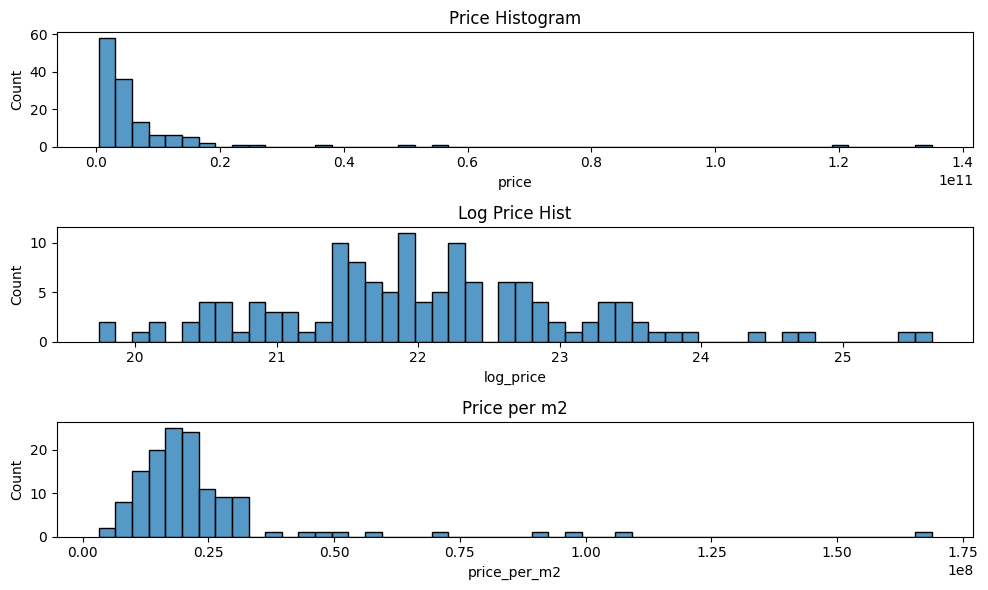

In [7]:
#visualize
from matplotlib import pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(3,1, figsize = (10,6))
sns.histplot(cleaned_df, x = 'price', bins = 50, ax = axes[0])
sns.histplot(cleaned_df, x = "log_price", bins = 50, ax = axes[1])
sns.histplot(cleaned_df, x='price_per_m2', bins = 50, ax = axes[2])
axes[0].set_title("Price Histogram")
axes[1].set_title("Log Price Hist")
axes[2].set_title("Price per m2")
plt.tight_layout()
plt.show()

### Price Data Stucture 

Harga properti memiliki distribusi yang sangat skewed ke kanan. Hal ini dapat disebabkab karena adanya beberapa properti mewah dengan harga jauh lebih tinggi dibandingkan mayoritas pasar.

Untuk mengurangi efek outlier dan memperjelas distribusi harga, transformasi logaritma diterapkan pada variabel harga.

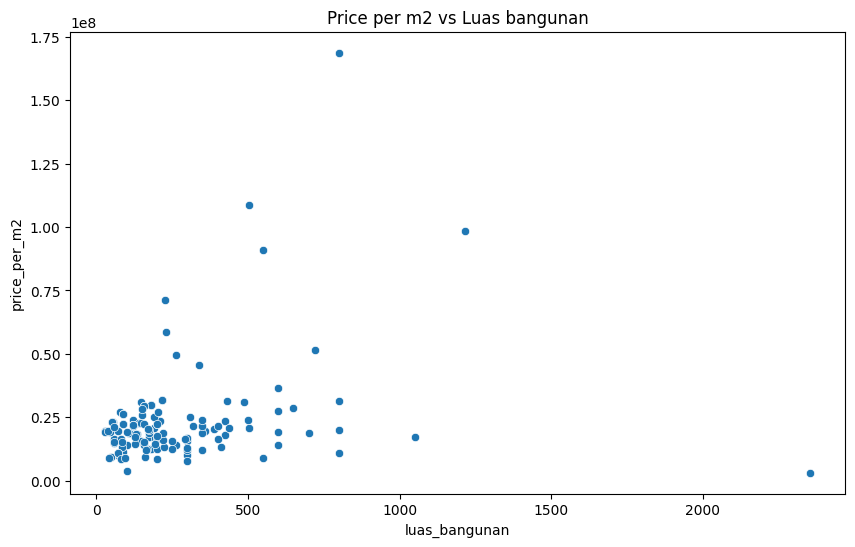

In [8]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data = cleaned_df, x = 'luas_bangunan', y = 'price_per_m2')
plt.title("Price per m2 vs Luas bangunan")
plt.show()

**Market Overview**
* Kebanyakan properti memiliki kisaran harga 100 - 250M IDR per m2
* Rumah berukuran 100 - 400 m2 mendominasi market daerah jakarta

**Outliers**
* Beberapa listing melebihi 500M IDR per m2
* Kemungkinan properti luxury atau anomali data

**Dinamik Pricing**
* Tidak ada korelasi antara luas bengunan dan efesiensi harga
* Kemungkinan lokasi properti lebih mempengaruhi harga

C:\Users\Acer\AppData\Local\Temp\ipykernel_13420\1756865225.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  scatterplots.set_xticklabels([f"{np.exp(t)/1e9:.0f}B" for t in ticks])
C:\Users\Acer\AppData\Local\Temp\ipykernel_13420\1756865225.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  scatterplots.set_xticklabels([f"{np.exp(t)/1e9:.0f}B" for t in ticks])
C:\Users\Acer\AppData\Local\Temp\ipykernel_13420\1756865225.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  scatterplots.set_xticklabels([f"{np.exp(t)/1e9:.0f}B" for t in ticks])
C:\Users\Acer\AppData\Local\Temp\ipykernel_13420\1756865225.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  sca

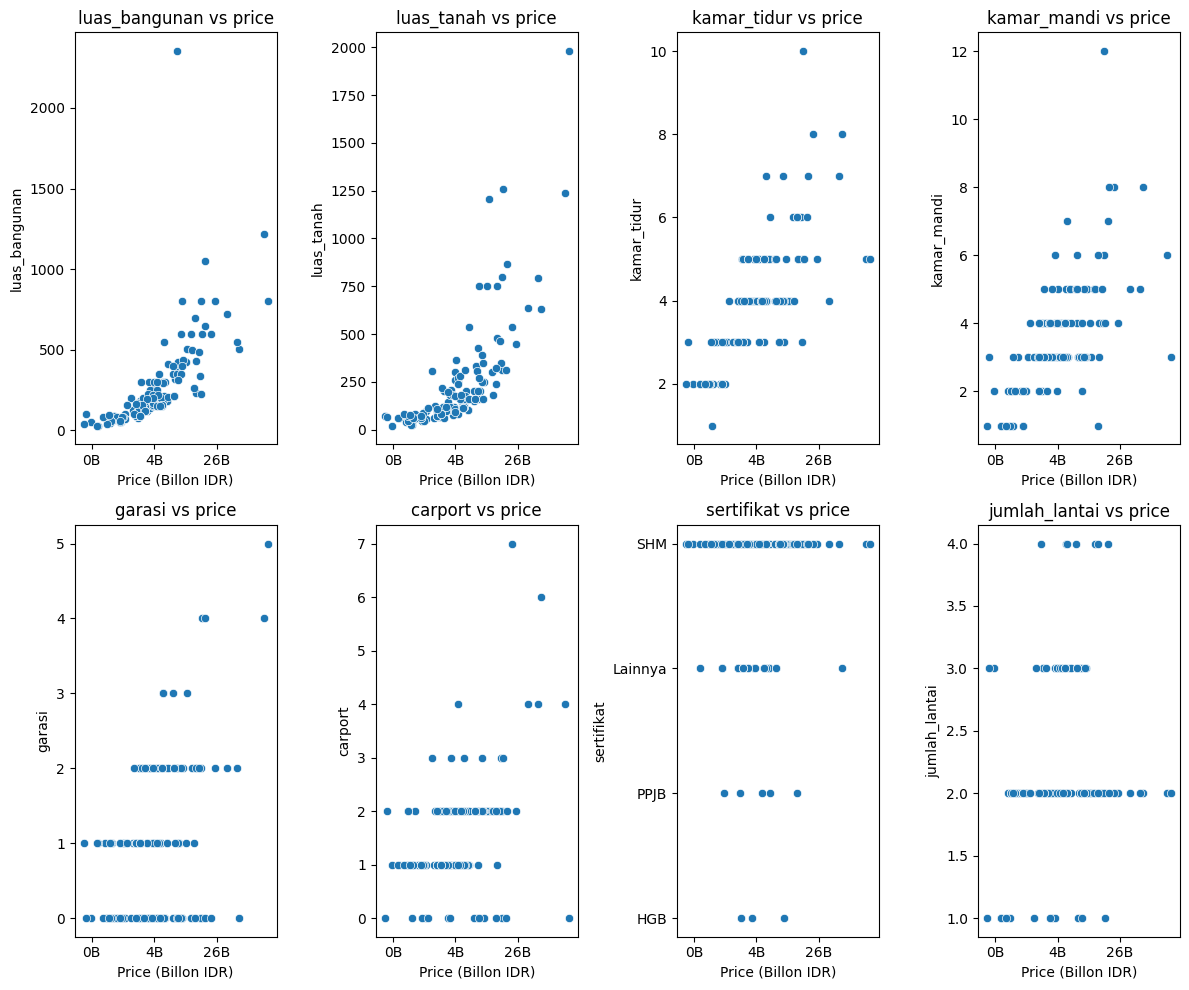

In [9]:
fig, axes = plt.subplots(2,4, figsize = (12, 10))

target_col = ['luas_bangunan', 'luas_tanah', 'kamar_tidur', 'kamar_mandi', 'garasi', 'carport', 'sertifikat', 'jumlah_lantai']
for i, col in enumerate(target_col):
    row = i // 4
    col_idx = i % 4
    scatterplots = sns.scatterplot(data = cleaned_df, x = "log_price", y = col, ax = axes[row, col_idx])
    ticks = scatterplots.get_xticks()
    scatterplots.set_xticklabels([f"{np.exp(t)/1e9:.0f}B" for t in ticks])
    axes[row, col_idx].set_xlabel("Price (Billon IDR)")
    axes[row, col_idx].set_title(f"{col} vs price")


plt.tight_layout()
plt.show()

### Korelasi Price
#### Korelasi
Harga menunjukkan kecenderungan meningkat seiring dengan bertambahnya luas bangunan dan luas tanah. Kedua variabel ini tampak memiliki hubungan paling jelas dengan harga dibandingkan variabel lainnya.

Fitur lain seperti jumlah kamar tidur, kamar mandi, garasi, dan carport juga menunjukkan hubungan positif terhadap harga, namun pola hubungan tidak terlihat kuat atau linear.

#### Market Overview

Market didominasi oleh rumah dengan luas bangunan kecil hingga menengah (~30 – 400 m²), dengan beberapa outlier pada rumah berukuran sangat besar (>700 m²).

Sebagian besar properti memiliki luas tanah sekitar 50 – 500 m², dengan beberapa properti berukuran sangat besar (>1000 m²).

#### Outliers
Terdapat beberapa properti dengan harga tinggi (>100M) yang dapat dianggap sebagai outlier. Kemungkinan merupakan properti mewah atau estate dengan ukuran bangunan dan tanah yang sangat besar atau anomali data

#### Variasi Harga
Market didominasi oleh rumah dengan luas bangunan kecil hingga menengah (~30 – 400 m²), dengan beberapa outlier pada rumah berukuran sangat besar (>700 m²).

Sebagian besar properti memiliki luas tanah sekitar 50 – 500 m², dengan beberapa properti berukuran sangat besar (>1000 m²).

#### Karakteristik Properti
Sebagian besar rumah memiliki:
- 3–6 kamar tidur
- 2–5 kamar mandi
- 1–2 lantai
- 0–2 garasi atau carport

Distribusi ini menunjukkan bahwa dataset didominasi oleh rumah keluarga menengah.

C:\Users\Acer\AppData\Local\Temp\ipykernel_13420\1447502160.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  frst_plot.set_yticklabels([f"{np.exp(t)/1e9:.0f}B" for t in ticks])


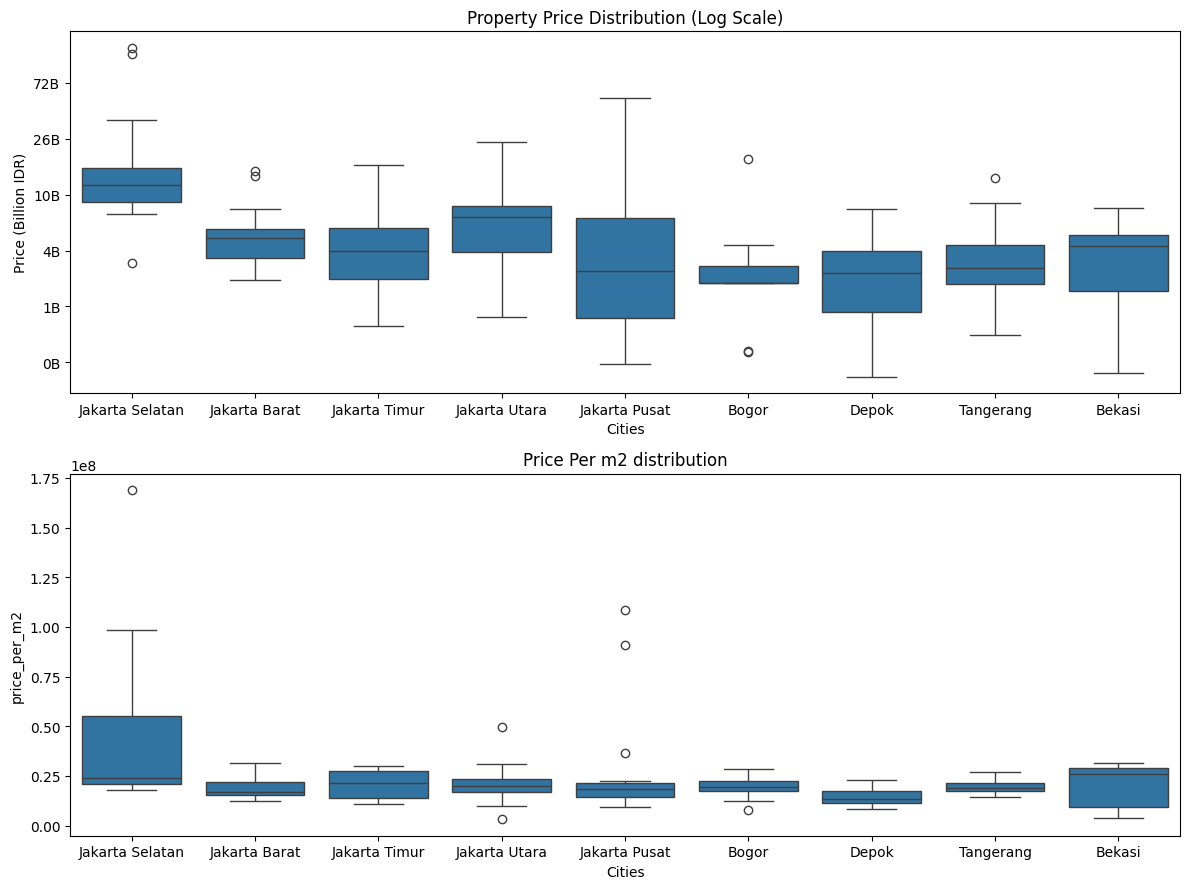

In [10]:
cleaned_df['city'] = cleaned_df['location'].str.extract(
    r"(Jakarta Selatan|Jakarta Barat|Jakarta Timur|Jakarta Utara|Jakarta Pusat|Bogor|Depok|Tangerang|Bekasi)"
)
fig, axes = plt.subplots(2,1, figsize = (12, 9))
frst_plot = sns.boxplot(data = cleaned_df, x = "city", y = "log_price", ax = axes[0])
ticks = frst_plot.get_yticks()
frst_plot.set_yticklabels([f"{np.exp(t)/1e9:.0f}B" for t in ticks])
axes[0].set_xlabel("Cities")
axes[0].set_ylabel("Price (Billion IDR)")
axes[0].set_title("Property Price Distribution (Log Scale)")

sns.boxplot(data=cleaned_df, x= "city", y = "price_per_m2", ax = axes[1])
axes[1].set_xlabel("Cities")
axes[1].set_title("Price Per m2 distribution")
plt.tight_layout()
plt.show()


### Price Distribution per City

Analisis menunjukkan perbedaan yang jelas antara area Jakarta dan kota satelit.

Jakarta Selatan memiliki median harga tertinggi baik dari sisi harga total maupun harga per m2, yang mencerminkan statusnya sebagai kawasan premium.

Kota satelit seperti Bogor, Depok, Tangerang, dan Bekasi memiliki harga properti yang lebih terjangkau dengan variasi harga yang lebih kecil.

Beberapa properti dengan harga sangat tinggi muncul sebagai outlier terutama di Jakarta Selatan dan Jakarta Pusat, yang kemungkinan merupakan properti mewah atau estate denga  luas tanah besar.

              city        median          mean  count
0           Bekasi  2.600000e+07  2.042650e+07     15
5  Jakarta Selatan  2.375000e+07  4.572132e+07     15
6    Jakarta Timur  2.128571e+07  2.079322e+07     14
7    Jakarta Utara  2.000000e+07  2.097434e+07     15
1            Bogor  1.933333e+07  1.892984e+07     15
8        Tangerang  1.892857e+07  1.940641e+07     14
4    Jakarta Pusat  1.851852e+07  2.879344e+07     15
3    Jakarta Barat  1.702857e+07  1.982438e+07     15
2            Depok  1.336323e+07  1.490772e+07     15


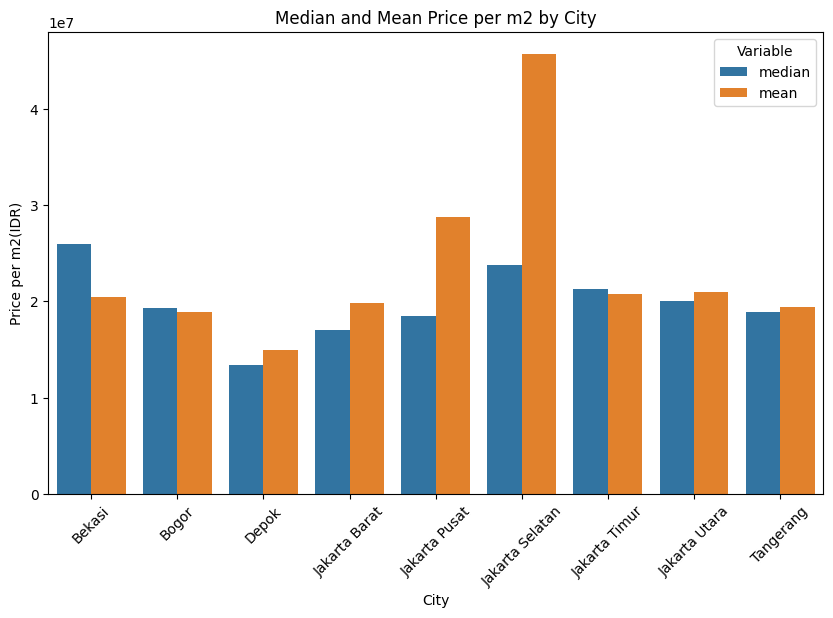

In [11]:
median_price_per_m2 = cleaned_df.groupby("city")['price_per_m2'].agg(
    median="median",
    mean="mean",
    count="count"
)

median_price_per_m2 = median_price_per_m2.reset_index()
print(median_price_per_m2.sort_values(by="median", ascending=False))

median_mean_melted = median_price_per_m2.melt(id_vars="city", value_vars=["median", "mean"], var_name="Variable", value_name = "Value" )
plt.figure(figsize=(10, 6))
sns.barplot(data = median_mean_melted, x = "city", y = "Value", hue = "Variable")
plt.title("Median and Mean Price per m2 by City")
plt.ylabel("Price per m2(IDR)")
plt.xlabel("City")

plt.xticks(rotation = 45)
plt.show()

### Price per m2 Median & Mean Analysis
1. Jakarta Selatan dan Jakarta Pusat memiliki mean jauh lebih besar dari median. Kemungkinan ada properti yang sangat mahal (luxury outlier) yang menarik mean ke atas

2. Bekasi median tertinggi tetapi mean tetap rendah. Banyak rumah kecil yang mahal(?) kemungkinan townhouse/cluster kecil

In [12]:
city_size = cleaned_df.groupby("city")["luas_bangunan"].mean().sort_values(ascending=False)

print("Mean Ukuran rumah per Kota\n")
print(city_size)

Mean Ukuran rumah per Kota

city
Jakarta Selatan    483.466667
Jakarta Utara      476.333333
Jakarta Timur      269.285714
Jakarta Barat      257.000000
Jakarta Pusat      237.466667
Tangerang          189.142857
Bekasi             178.466667
Depok              176.533333
Bogor              169.466667
Name: luas_bangunan, dtype: float64


In [13]:
value_analysis = cleaned_df.groupby("city").agg(
    median_price_per_m2 = ("price_per_m2", "median"),
    avg_household_size = ("luas_bangunan", "mean"),
    count = ("price", "count")
)

value_analysis = value_analysis.sort_values(by = "median_price_per_m2", ascending=False)
print(value_analysis)

                 median_price_per_m2  avg_household_size  count
city                                                           
Bekasi                  2.600000e+07          178.466667     15
Jakarta Selatan         2.375000e+07          483.466667     15
Jakarta Timur           2.128571e+07          269.285714     14
Jakarta Utara           2.000000e+07          476.333333     15
Bogor                   1.933333e+07          169.466667     15
Tangerang               1.892857e+07          189.142857     14
Jakarta Pusat           1.851852e+07          237.466667     15
Jakarta Barat           1.702857e+07          257.000000     15
Depok                   1.336323e+07          176.533333     15


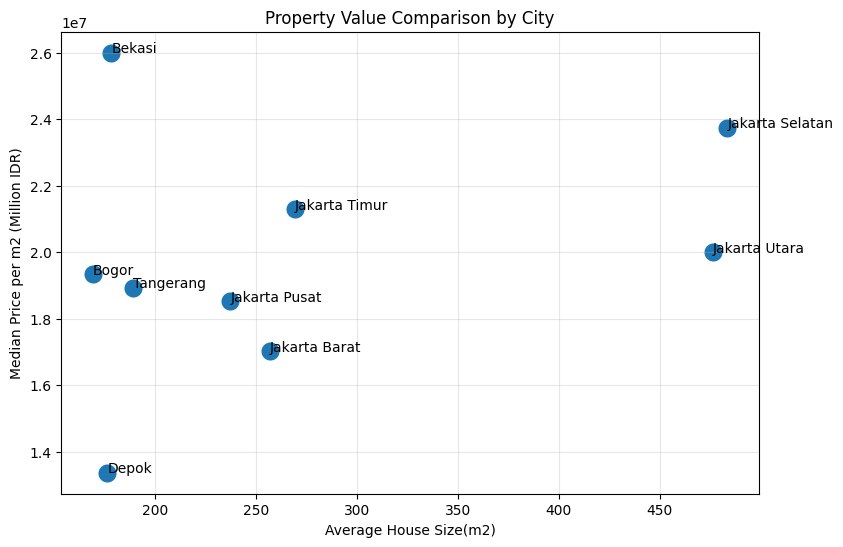

In [14]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data = value_analysis,
    x = "avg_household_size",
    y = "median_price_per_m2",
    s = 200
)

for i in value_analysis.index:
    plt.text(
        value_analysis.loc[i, "avg_household_size"],
        value_analysis.loc[i, "median_price_per_m2"],
        i
    )
plt.grid(alpha = 0.3)
plt.xlabel("Average House Size(m2)")
plt.ylabel("Median Price per m2 (Million IDR)")
plt.title("Property Value Comparison by City")

plt.show()

### Property value by City
1. Jakarta Selatan \
&nbsp;Jakarta Selatan menunjukkan kombinasi harga per meter persegi yang tinggi dengan ukuran rumah yang relatif besar, mencerminkan karakteristik pasar properti premium

2. Jakarta Utara \
&nbsp;Jakarta Utara menunjukkan ukuran rumah rata-rata terbesar dalam dataset dengan price per m2 yang masih relatif tinggi.

3. Bogor, Tangerang, Bekasi \
&nbsp;Ketiga lokasi ini menunjukkan harga yang sangat mahal dengan ukuran rumah yang relatif kecil, hal ini kemungkinan karena adanya rumah tipe cluster dengan luas bangunan yang terbatas
, rumah minimalist modern,lokasi elit, hunian urban/kondominium, atau anomali pada data

4. Depok \
&nbsp;Depok menawarkan harga price per m2 yang paling rendah dalam dataset. Ini menunjukkan pasar yang lebih affordable dengan kaviat ukuran rumah yang relatif kecil

5. Jakarta Barat \
&nbsp;Jakarta Barat menunjukkan luas bangunan yang cukup luas dengan harga per m2 relatif moderat, menjadikan alternatif menarik bagi pembeli yang mencari rumah lebih luas dengan harga lebih terjangkau

6. Jakarta Barat & Pusat \
&nbsp;Kedua lokasi ini meunjukkan market menengah yang menunjukkan keseimbangan antara ukuran rumah dan harga per m2. 